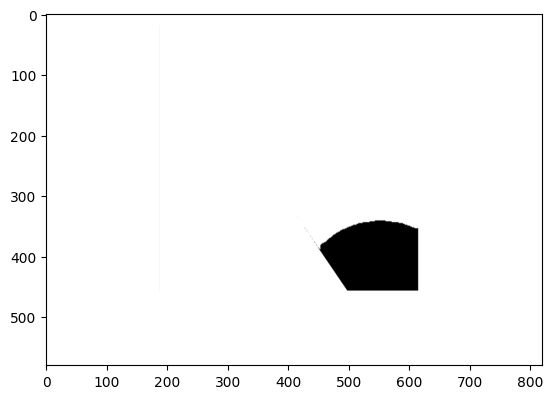

Number of black pixels in p0:  15297
Area of black pixels in square millimeters:  38.24


In [51]:
import cv2
import os
from matplotlib import pyplot as plt
import numpy as np
areas = []
p0 = cv2.imread('../resized_images/p0.bmp', cv2.IMREAD_GRAYSCALE)
p0_resized = cv2.resize(p0, (820, 580))
cv2.imwrite('../resized_images/p0.bmp', p0_resized)
plt.imshow(p0_resized, cmap='gray')
plt.show()

black_pixel_count = np.sum(p0_resized == 0)
print("Number of black pixels in p0: ", black_pixel_count)
# Calculate the area of black pixels in square millimeters
black_area_mm = black_pixel_count * (29/580)**2
areas.append(black_area_mm)
print("Area of black pixels in square millimeters: ", round(black_area_mm, 2))

File path:  ../resized_images/p2-1.bmp
Number of black pixels:  16447
Area of black pixels in square millimeters:  41.12


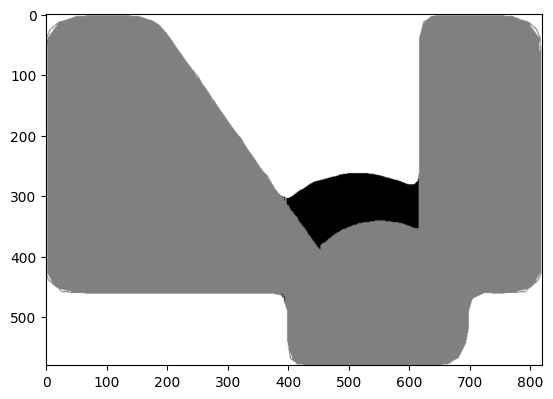

File path:  ../resized_images/p3-1.bmp
Number of black pixels:  19681
Area of black pixels in square millimeters:  49.2


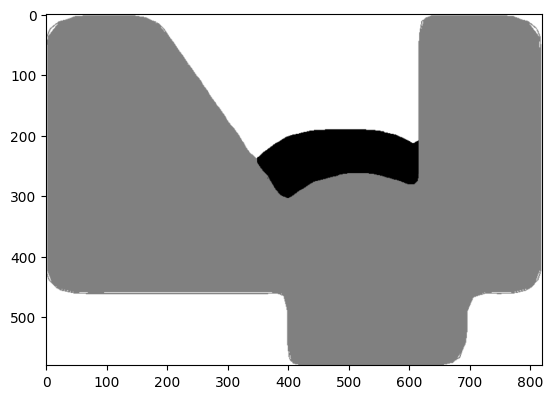

File path:  ../resized_images/p4-1.bmp
Number of black pixels:  15886
Area of black pixels in square millimeters:  39.72


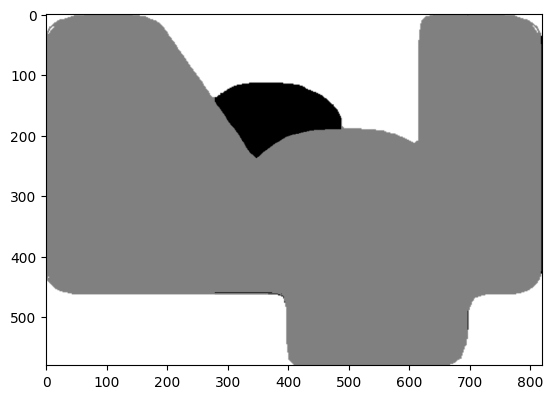

File path:  ../resized_images/p4-2.bmp
Number of black pixels:  17517
Area of black pixels in square millimeters:  43.79


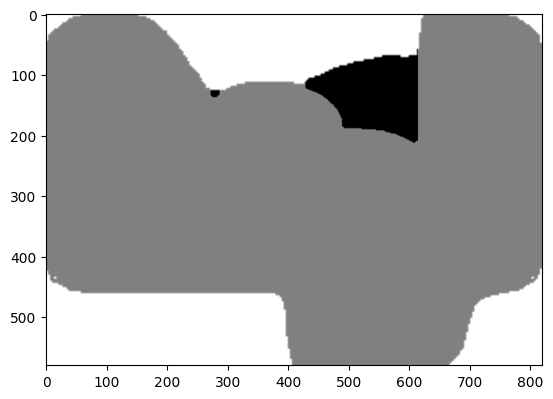

File path:  ../resized_images/p5-1.bmp
Number of black pixels:  14040
Area of black pixels in square millimeters:  35.1


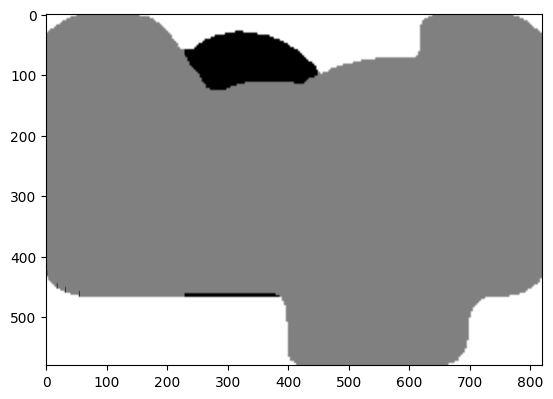

File path:  ../resized_images/p5-2.bmp
Number of black pixels:  17111
Area of black pixels in square millimeters:  42.78


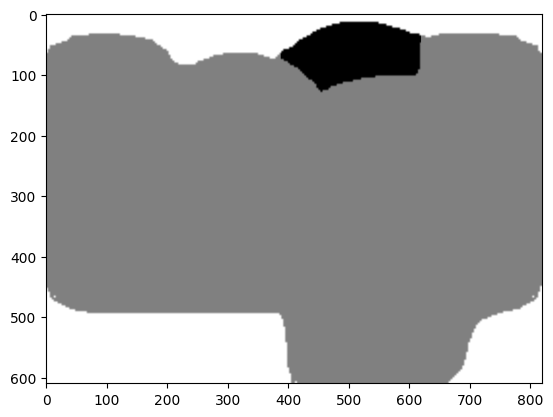

File path:  ../resized_images/p6-1.bmp
Number of black pixels:  21686
Area of black pixels in square millimeters:  54.22


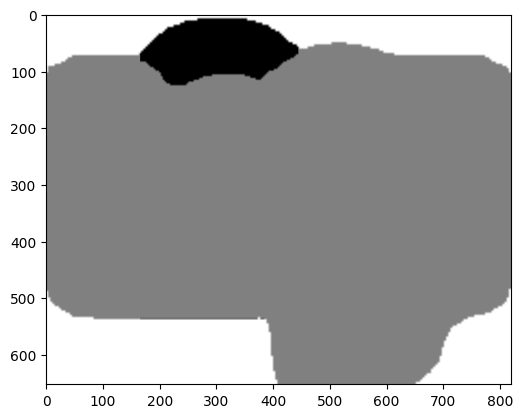

File path:  ../resized_images/p6-2.bmp
Number of black pixels:  11766
Area of black pixels in square millimeters:  29.42


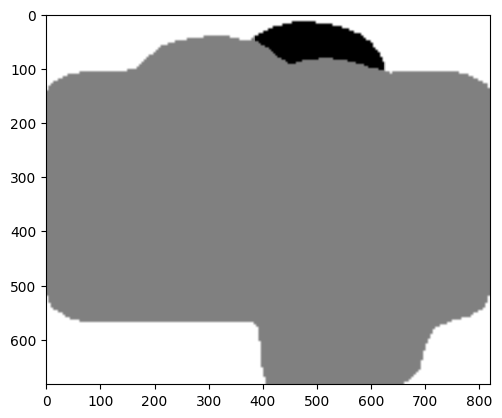

In [64]:
import cv2
import os
from matplotlib import pyplot as plt
import numpy as np
# Define the paths to the cropped image folders
image_foder = '../resized_images/'
images= os.listdir(image_foder)
# print("Images in the folder: ", images) 
# Sort the images to ensure they are in the correct order



for i in range(1, len(images) - 1):
    file_p1 = os.path.join(image_foder, images[i])
    
    file_p2 = os.path.join(image_foder, images[i+1])
    print("File path: ", file_p2)

# file_p1 = os.path.join(image_foder, 'p6-1.bmp')
# file_p2 = os.path.join(image_foder, 'p6-2.bmp')
    
    # Read the images
    img_p1 = cv2.imread(file_p1, cv2.IMREAD_GRAYSCALE)
    img_p2 = cv2.imread(file_p2, cv2.IMREAD_GRAYSCALE)

    if img_p1.shape[0] < img_p2.shape[0]:
        padding = img_p2.shape[0] - img_p1.shape[0]
        img_p1 = cv2.copyMakeBorder(img_p1, padding, 0, 0, 0, cv2.BORDER_CONSTANT, value=255)

        
    extracted_image = cv2.subtract(img_p1, img_p2)      

    contours, _ = cv2.findContours(extracted_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Iterate over contours
    for contour in contours:
        area = cv2.contourArea(contour)
        if area < 1000:
            cv2.drawContours(extracted_image, [contour], -1, 0, thickness=cv2.FILLED)


    white_pixel_threshold = 5
    for col in range(extracted_image.shape[1]):
        white_pixel_count = np.sum(extracted_image[:, col] == 255)
        if white_pixel_count <= white_pixel_threshold:
            extracted_image[:, col] = 0  # Convert the column to black pixels

    extracted_image = cv2.bitwise_not(extracted_image)

    black_pixel_count = np.sum(extracted_image == 0)
    print("Number of black pixels: ", black_pixel_count)
    # Calculate the area of black pixels in square millimeters
    black_area_mm = black_pixel_count * (29/580)**2
    areas.append(black_area_mm)
    print("Area of black pixels in square millimeters: ", round(black_area_mm, 2))

    plt.imshow(extracted_image, cmap='gray')
    plt.imshow(img_p2, cmap='gray', alpha=0.5)  # Overlay the original image with transparency
    plt.axis('on')  # Turn off axis numbers
    plt.show()


In [53]:
print("Areas of black pixels in square millimeters: ", np.round(areas, 2))

Areas of black pixels in square millimeters:  [38.24 41.12 49.2  39.72 43.79 35.1  42.78 54.22 29.42]


    37.11   41.12  49.2 39.72  43.79  35.1 42.78 54.22  29.42

In [12]:
import numpy as np
# Define parameters for the calculation
eta = 0.95  # Efficiency (90-98%)
d = 1.2  # Diameter of welding wire (mm)
vf = 11.6  # Wire feed speed (m/min)
vw = [30, 27, 24, 27, 18, 30, 27, 18, 30]
vw = np.asarray(vw)

# Convert vf from m/min to mm/s
vf_mm_s = vf * 1000 / 60

# Convert vw from cm/min to mm/s
vw_mm_s = vw * 10 / 60

# Calculate the weld cross-sectional area S (mm^2)
S = (eta * np.pi * d**2 * vf_mm_s) / (4 * vw_mm_s)

# Print the results
# print(np.round(S, 2))
print(f"Weld cross-sectional area S: {np.round(S, 2)} mm^2")

Weld cross-sectional area S: [41.54 46.16 51.93 46.16 69.24 41.54 46.16 69.24 41.54] mm^2


C:\Users\kevin\AppData\Local\Temp\ipykernel_16420\945170521.py:37: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_16420\945170521.py:37: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_16420\945170521.py:37: UserWarning: Glyph 24207 (\N{CJK UNIFIED IDEOGRAPH-5E8F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_16420\945170521.py:37: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_16420\945170521.py:37: UserWarning: Glyph 28938 (\N{CJK UNIFIED IDEOGRAPH-710A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_16420\945170521.py:37: UserWarning: Glyph 32541 (\N{CJK 

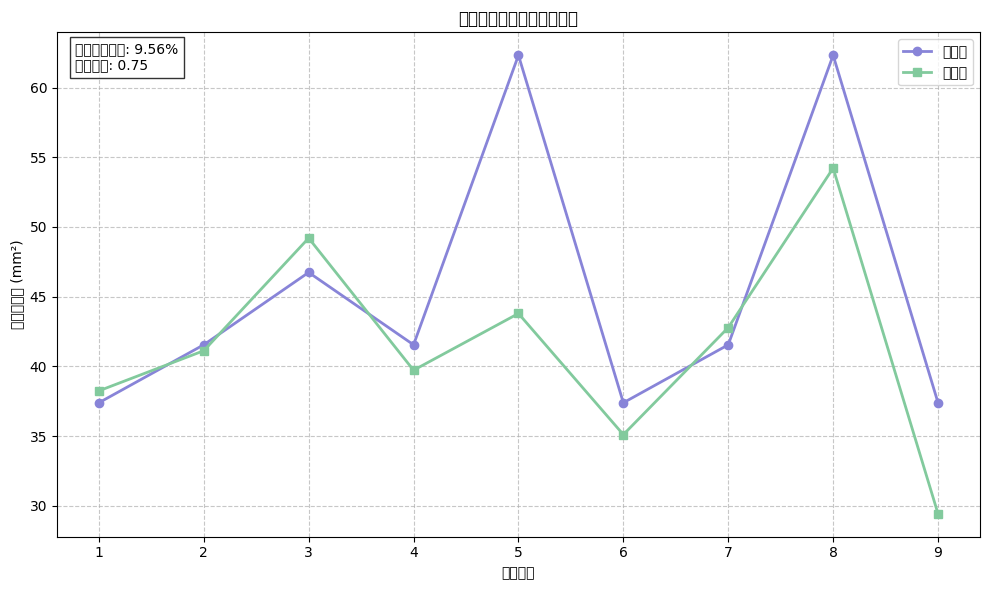

平均相对误差: 9.56%
相关系数: 0.75

各样本相对误差:
样本1: 2.28%
样本2: 1.02%
样本3: 5.27%
样本4: 4.39%
样本5: 29.73%
样本6: 6.11%
样本7: 2.98%
样本8: 12.99%
样本9: 21.31%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
actual = np.array([41.54, 46.16, 51.93, 46.16, 69.24, 41.54, 46.16, 69.24, 41.54])
actual = actual * 0.9
simulated = np.array([38.24, 41.12, 49.2, 39.72, 43.79, 35.1, 42.78, 54.22, 29.42])

# Calculate errors
relative_errors = np.abs(actual - simulated) / actual * 100
mean_error = np.mean(relative_errors)

# Calculate correlation coefficient
correlation = np.corrcoef(actual, simulated)[0,1]

# Create chart
plt.figure(figsize=(10, 6))
x = range(1, len(actual) + 1)

# Plot lines
plt.plot(x, actual, 'o-', label='Actual Values', color='#8884d8', linewidth=2)
plt.plot(x, simulated, 's-', label='Simulated Values', color='#82ca9d', linewidth=2)

# Set chart properties
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Sample Index')
plt.ylabel('Weld Cross-Sectional Area (mm²)')
plt.title('Comparison of Actual and Simulated Weld Cross-Sectional Areas')
plt.legend()

# Add error information
plt.text(0.02, 0.98, f'Average Relative Error: {mean_error:.2f}%\nCorrelation Coefficient: {correlation:.2f}', 
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8),
         verticalalignment='top')

plt.tight_layout()
plt.show()

# Print detailed data
print(f"Average Relative Error: {mean_error:.2f}%")
print(f"Correlation Coefficient: {correlation:.2f}")
print("\nRelative Errors for Each Sample:")
for i, error in enumerate(relative_errors, 1):
    print(f"Sample {i}: {error:.2f}%")